<a href="https://colab.research.google.com/github/Evelyn-Rojas/Procesos-Estocasticos/blob/main/MatrizFundamental.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<font color="mediumorchid">**Evelyn Tania Rojas Roa**

<font color="mediumorchid">**Procesos estocásticos**

---



#<font color="mediumpurple">  **Serpientes y escaleras**

---



* Resolver analíticamente y por simulación.

* ¿Cuál es el número promedio de tiradas necesarias para terminar el juego de serpientes y escaleras en el tablero de la imagen adjunta?

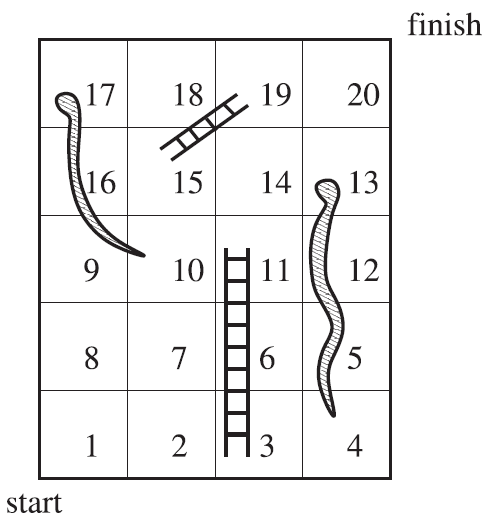

In [3]:
#Importamos las librerias necesarias
import numpy as np #Para uso de matrices
import sympy as sp #Calculo simbólico (matrices)
import random as r #Generación de números

<font color="tomato">**1. Obtenemos la matriz de transición**

In [4]:
import pandas as pd
n_casillas = 20 #Configuración del tablero
shortcuts = {3: 11, 15: 19, 13: 4, 17: 10} # Definimos los saltos: {origen: destino}
# Matriz P de 21x21 (Estados 0 al 20), donde el estado 0 es la posición inicial "fuera" del tablero
P = np.zeros((n_casillas + 1, n_casillas + 1))
# Llenado de probabilidades para cada estado i (excepto el final)
for i in range(n_casillas):
    for dado in range(1, 7):
        pos_tentativa = i + dado
        #Si se pasa de 20, se queda quieto en la casilla i
        if pos_tentativa > n_casillas:
            destino_final = i
        else:
            #Aplicar efecto de serpiente o escalera si existe
            destino_final = shortcuts.get(pos_tentativa, pos_tentativa)

        #Sumar la probabilidad (1/6) a la transición i -> destino_final
        P[i, destino_final] += 1/6

#Estado 20 es absorbente (Meta)
P[20, 20] = 1.0

In [5]:
nombres_estados = [f"E{i}" for i in range(21)]
df_matriz = pd.DataFrame(P, index=nombres_estados, columns=nombres_estados)
print("Matriz de Transición P (primeras filas):")
print(df_matriz.iloc[:21, :21]) #Muestra la matriz

Matriz de Transición P (primeras filas):
      E0        E1        E2   E3        E4        E5        E6        E7  \
E0   0.0  0.166667  0.166667  0.0  0.166667  0.166667  0.166667  0.000000   
E1   0.0  0.000000  0.166667  0.0  0.166667  0.166667  0.166667  0.166667   
E2   0.0  0.000000  0.000000  0.0  0.166667  0.166667  0.166667  0.166667   
E3   0.0  0.000000  0.000000  0.0  0.166667  0.166667  0.166667  0.166667   
E4   0.0  0.000000  0.000000  0.0  0.000000  0.166667  0.166667  0.166667   
E5   0.0  0.000000  0.000000  0.0  0.000000  0.000000  0.166667  0.166667   
E6   0.0  0.000000  0.000000  0.0  0.000000  0.000000  0.000000  0.166667   
E7   0.0  0.000000  0.000000  0.0  0.166667  0.000000  0.000000  0.000000   
E8   0.0  0.000000  0.000000  0.0  0.166667  0.000000  0.000000  0.000000   
E9   0.0  0.000000  0.000000  0.0  0.166667  0.000000  0.000000  0.000000   
E10  0.0  0.000000  0.000000  0.0  0.166667  0.000000  0.000000  0.000000   
E11  0.0  0.000000  0.000000  0.0  

<font color="tomato">**Clases de equivalencia**

En este sistema tenemos dos clases principales de estados
* Clase Transitoria ($C_1$): Incluye los estados {0, 1, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 16, 18, 19}
* Las casillas 3, 13, 15 y 17 no forman parte de las clases porque son estados de paso instantáne ya que en cuanto caes en ellas, te mueves a otra posición, por lo que su probabilidad de permanencia es cero.
* Clase Absorbente ($C_2$): Incluye únicamente el estado {20}.

<font color="tomato">**Matriz fundamental**

En este caso como la matriz tiene un solo estado absorbente por lo tanto la matriz fundamental será ella misma.

Para resolver el promedio de tiradas, solo se necesita la submatriz $Q$ de $20 \times 20$ que contiene las probabilidades entre las casillas antes de la meta. El número promedio de tiradas desde el inicio es el primer elemento del vector resultante de:$$\mathbf{E} = (I - Q)^{-1} \mathbf{1}$$

**Solución analítica**

Sea $E_i$ el número esperado de tiradas para llegar a la meta desde la casilla $i$. Queremos hallar $E_0$.La ecuación general para cada estado es:$$E_i = 1 + \frac{1}{6} \sum_{j=1}^{6} E_{next(i+j)}$$Donde next(s) es la posición final tras considerar serpientes y escaleras.

Matriz de Transición

Definimos una matriz de transición $P$ de $20 \times 20$ (sin contar el estado 20 que es absorbente). El número esperado de pasos se obtiene resolviendo:$$(I - Q) \mathbf{e} = \mathbf{1}$$Donde:

$Q$ es la submatriz de estados transitorios (casillas 0 a 19).

$\mathbf{e}$ es el vector de esperanzas $[E_0, E_1, \dots, E_{19}]^T$.

$\mathbf{1}$ es un vector de unos.

Cálculo de la Esperanza :$$E_0 = \sum_{j=0}^{19} N_{0,j} \approx 11.6001$$

In [6]:
saltos = {3: 11, 15: 19, 13: 4, 17: 10} # Definición del tablero: {origen: destino}
def get_next_pos(pos):
    return saltos.get(pos, pos)
#Montecarlo
def simulate_game():
    pos = 0
    turns = 0
    while pos < 20:
        roll = np.random.randint(1, 7)
        if pos + roll <= 20:
            pos += roll
            pos = get_next_pos(pos)
        turns += 1
    return turns
n_simulaciones= 10**4
results = [simulate_game() for _ in range(n_simulaciones)]
print(f"Promedio por simulación: {np.mean(results):.4f}")

#Solución analítica (Método matricial)
Q = np.zeros((20, 20))

for i in range(20):
    for die in range(1, 7):
        next_p = i + die
        if next_p > 20:
            next_p = i # Se queda quieto si excede

        if next_p < 20:
            final_p = get_next_pos(next_p)
            # Si la serpiente/escalera lleva a la meta (20), no se suma a Q
            if final_p < 20:
                Q[i, final_p] += 1/6
        # Si final_p == 20, la probabilidad cae en la parte absorbente (no en Q)

I = np.eye(20)
# (I - Q) * E = 1  => E = inv(I - Q) * 1
E = np.linalg.solve(I - Q, np.ones(20))

print(f"Resultado analítico (E_0): {E[0]:.4f}")

Promedio por simulación: 11.6112
Resultado analítico (E_0): 11.6001


<font color="mediumorchid">**Ejercicio 2:**

**¿Cuál es la probabilidad de que el ratón, iniciando  en la casilla 0, alcance la comida?**

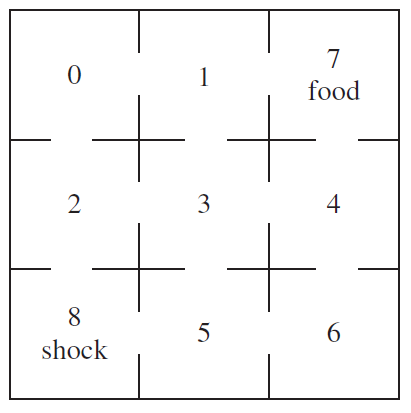

<font color="tomato"> **Clasificación de estados**

$C_1$: {0, 1, 2, 3, 4, 5, 6}, estados transitorios

$C_2$: {7}, estado absorbente y recurrente

$C_3$: {8}, estado absorbente y recurrente

El sistema es aperiódico.

La probabilidad de que el ratón sea absorbido por el estado $j$ (comida o choque) habiendo iniciado en el estado $i$ se obtiene mediante:$$B = N \times R$$Para el estado inicial 0, el cálculo de la primera fila de $B$ resulta en:$$b_{0,7} = \sum_{k \in S_T} n_{0,k} \cdot r_{k,7}$$

Debido a la simetría al resolver el sistema lineal de ecuaciones: Las probabilidades de éxito desde los nodos centrales (0, 3, 6) se equilibran.

Desde el nodo 0, tendremos:
$$B_{0, \text{comida}} = 0.5$$$$B_{0, \text{choque}} = 0.5$$

> Obtenemos la matriz de transición

In [7]:
M=sp.Matrix([[0.0, 0.5,0.5,0,0,0,0,0,0], [1/3, 0.0,0.0,1/3,0,0,0,1/3,0.0],  [1/3, 0.0,0.0,1/3,0,0,0,0.0,1/3], [0.0,1/4,1/4,0.0,1/4,1/4,0.0,0.0,0.0],[0.0,0.0,0.0,1/3, 0.0,0.0,1/3,1/3,0.0],[0.0,0.0,0.0,1/3, 0.0,0.0,1/3,0.0,1/3],
 [0.0,0.0,0.0,0.0,1/2,1/2,0.0,0.0,0.0],[0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0],[0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0]])
M

Matrix([
[              0.0,  0.5,  0.5,                 0,    0,    0,                 0,                 0,                 0],
[0.333333333333333,  0.0,  0.0, 0.333333333333333,    0,    0,                 0, 0.333333333333333,               0.0],
[0.333333333333333,  0.0,  0.0, 0.333333333333333,    0,    0,                 0,               0.0, 0.333333333333333],
[              0.0, 0.25, 0.25,               0.0, 0.25, 0.25,               0.0,               0.0,               0.0],
[              0.0,  0.0,  0.0, 0.333333333333333,  0.0,  0.0, 0.333333333333333, 0.333333333333333,               0.0],
[              0.0,  0.0,  0.0, 0.333333333333333,  0.0,  0.0, 0.333333333333333,               0.0, 0.333333333333333],
[              0.0,  0.0,  0.0,               0.0,  0.5,  0.5,               0.0,               0.0,               0.0],
[              0.0,  0.0,  0.0,               0.0,  0.0,  0.0,               0.0,               1.0,               0.0],
[              0.0,  0.

Para hallar la probabilidad de alcanzar un estado absorbente específico, usamos la fórmula:
$$B = (I - Q)^{-1} R$$

Donde:

* $Q$ es la submatriz de transiciones entre estados transitorios.
* $R$ es la submatriz de transiciones de estados transitorios a absorbentes.
* $N = (I - Q)^{-1}$ es la Matriz Fundamental.

In [17]:
#Añadimos las casillas (diccionario de salidas posibles por casilla)
adj = {
    0: [1, 2],
    1: [0, 3, 7],
    2: [0, 3, 8],
    3: [1, 2, 4, 5],
    4: [7, 3, 6],
    5: [3, 8, 6],
    6: [4, 5]
}
#Clasificación de estados
transitorios = [0, 1, 2, 3, 4, 5, 6]
absorbentes = [7, 8] # 7=Comida, 8=Choque
#Construimos las matrices Q y R
Q = np.zeros((7, 7))
R = np.zeros((7, 2))
for i, s in enumerate(transitorios):
    vecinos = adj[s]
    prob = 1.0 / len(vecinos)
    for v in vecinos:
        if v in transitorios:
            j = transitorios.index(v)
            Q[i, j] = prob
        else:
            j = absorbentes.index(v)
            R[i, j] = prob

#Cálculo de la Matriz Fundamental N = (I - Q)^-1
I = np.eye(7)
N = np.linalg.inv(I - Q)

#Probabilidades de Absorción B = N * R
B = np.dot(N, R)

print(f"Probabilidad de llegar a la COMIDA (7) desde la casilla 0: {B[0, 0]:.4f}")
print(f"Probabilidad de llegar al CHOQUE (8) desde la casilla 0: {B[0, 1]:.4f}")

Probabilidad de llegar a la COMIDA (7) desde la casilla 0: 0.5000
Probabilidad de llegar al CHOQUE (8) desde la casilla 0: 0.5000


> Forma alterna de resolución

 <font color="lightseagreen"> **Simulación de una Cadena de Markov**


**Entrada:**   
Estado inicial $\alpha$, matriz de transición $P$, número de pasos $n$.

**Salida:**  
$X_0, X_1, \ldots, X_n$

1. Generar $X_0 \  ∼ \alpha$.

2. Para $i = 1,2,\ldots,n$ hacer:

   Si $X_{i-1} = j$:

   - Tomar el renglón $j$ de la matriz $P$.
   - Generar $X_i$ con distribución aproximada a ese renglón, es decir  
     $X_i \ \sim\ p_{j\cdot}$.


---

In [19]:
alphaM= sp.Matrix([1.0,0,0,0,0,0,0,0,0]) #Vector del estado inicial

In [31]:
def CadenaMarkov(p, alpha1,n):
  estados = np.arange(len(alpha1))
  x = []
  X0 = r.choices(estados, weights=[float(v) for v in alpha1])[0]
  x.append(int(X0))
  for i in range(1, n+1):
    j = x[i-1]                   # estado anterior
    probs = [float(v) for v in p.row(j)]   # renglón j de P
    Xi = r.choices(estados, weights=probs)[0]   # tomar el número
    x.append(int(Xi))
  return x

In [32]:
l=[]
n=10**3
sum7=0
sum8=0
for i in range (n):
  x=CadenaMarkov(M,alphaM,n)
  if 7 in x:
    sum7=sum7+1
  if 8 in x:
    sum8=sum8+1
  l.append(x)

In [33]:
print("Probabilidad del estado 7 (comida):", sum7/n)
print("Probabilidad del estado 8 (choque):", sum8/n)

Probabilidad del estado 7 (comida): 0.495
Probabilidad del estado 8 (choque): 0.505
